# AeroGuard — Exploration de la flotte simulée
But : visualiser l'usure des moteurs, puis mesurer avec combien de vols d'avance le score z détecte la panne.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from aeroguard.detection import score_z, detecter_anomalies

flotte = pd.read_parquet("../data/processed/flotte_simulee.parquet")
flotte.head()

,unit,cycle,T48,P30,hs,rul
0,1,1,523.752256,45.486972,1,82
1,1,2,524.702824,44.530598,1,81
2,1,3,510.244824,45.012494,1,80
3,1,4,513.489102,45.480747,1,79
4,1,5,520.639202,45.446531,1,78


In [3]:
print("Taille :", flotte.shape)
print("Nombre de moteurs :", flotte["unit"].nunique())
flotte.describe().round(1)

Taille : (993, 6)
Nombre de moteurs : 10


,unit,cycle,T48,P30,hs,rul
count,993.0,993.0,993.0,993.0,993.0,993.0
mean,5.6,51.0,531.1,43.8,0.6,50.0
std,2.9,30.1,22.6,2.4,0.5,30.1
min,1.0,1.0,505.7,32.5,0.0,0.0
25%,3.0,25.0,518.3,43.2,0.0,24.0
50%,6.0,50.0,522.4,44.5,1.0,49.0
75%,8.0,75.0,532.7,45.3,1.0,74.0
max,10.0,118.0,642.3,47.8,1.0,117.0


## 1. La température de la flotte, vol après vol

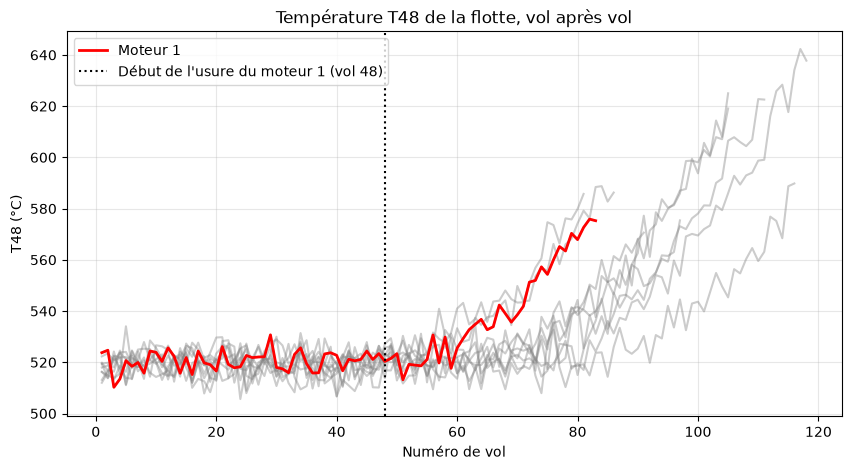

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

for unit, moteur in flotte.groupby("unit"):
    ax.plot(moteur["cycle"], moteur["T48"], color="gray", alpha=0.4)

moteur_1 = flotte[flotte["unit"] == 1]
debut_usure = moteur_1.loc[moteur_1["hs"] == 1, "cycle"].max()
ax.plot(moteur_1["cycle"], moteur_1["T48"], color="red", linewidth=2, label="Moteur 1")
ax.axvline(debut_usure, color="black", linestyle=":", label=f"Début de l'usure du moteur 1 (vol {debut_usure})")

ax.set_title("Température T48 de la flotte, vol après vol")
ax.set_xlabel("Numéro de vol")
ax.set_ylabel("T48 (°C)")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../results/figures/01_flotte_T48.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Tous les moteurs alignés sur leur panne
Au lieu du numéro de vol, on utilise le nombre de vols restants : tous les moteurs finissent à 0.

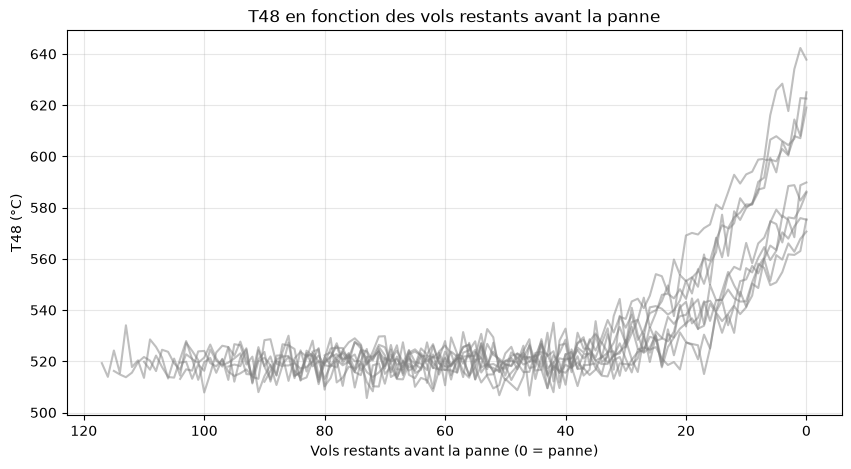

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for unit, moteur in flotte.groupby("unit"):
    ax.plot(moteur["rul"], moteur["T48"], color="gray", alpha=0.5)

ax.invert_xaxis()
ax.set_title("T48 en fonction des vols restants avant la panne")
ax.set_xlabel("Vols restants avant la panne (0 = panne)")
ax.set_ylabel("T48 (°C)")
ax.grid(alpha=0.3)
fig.savefig("../results/figures/01_T48_vs_rul.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. La détection par score z
- Entraînement : moteurs 1 à 5, vols sains uniquement → on apprend le « normal ».
- Test : moteurs 6 à 10, jamais vus → on mesure la détection.

In [6]:
entrainement = flotte[flotte["unit"] <= 5]
test = flotte[flotte["unit"] > 5].copy()

t48_sains = entrainement.loc[entrainement["hs"] == 1, "T48"]
print(f"Normal appris : {t48_sains.mean():.1f} °C, écart-type {t48_sains.std(ddof=0):.2f} °C")

test["z"] = score_z(test["T48"], t48_sains)
test["alerte"] = detecter_anomalies(test["z"], seuil=3.0)
test.tail()

Normal appris : 519.6 °C, écart-type 4.74 °C


,unit,cycle,T48,P30,hs,rul,z,alerte
988,10,114,628.376645,35.178837,0,4,22.937026,True
989,10,115,617.669578,34.328460,0,3,20.678770,True
990,10,116,634.074273,33.424178,0,2,24.138728,True
991,10,117,642.310532,35.694153,0,1,25.875859,True
992,10,118,637.765950,32.543049,0,0,24.917349,True


In [7]:
bilan = []

for unit, moteur in test.groupby("unit"):
    debut_usure = moteur.loc[moteur["hs"] == 1, "cycle"].max()
    alertes_vraies = moteur[moteur["alerte"] & (moteur["hs"] == 0)]
    premiere_alerte = alertes_vraies["cycle"].min()
    avance = moteur.loc[moteur["cycle"] == premiere_alerte, "rul"].iloc[0]
    fausses_alarmes = (moteur["alerte"] & (moteur["hs"] == 1)).sum()

    bilan.append({
        "moteur": unit,
        "début usure": debut_usure,
        "1re alerte": premiere_alerte,
        "retard (vols)": premiere_alerte - debut_usure,
        "avance d'alerte (vols)": avance,
        "fausses alarmes": fausses_alarmes,
    })

bilan = pd.DataFrame(bilan)
bilan

,moteur,début usure,1re alerte,retard (vols),avance d'alerte (vols),fausses alarmes
0,6,61,76,15,29,0
1,7,59,76,17,15,0
2,8,66,82,16,15,0
3,9,60,63,3,42,0
4,10,69,85,16,33,1


In [9]:
retard_moyen = bilan["retard (vols)"].mean()
avance_moyenne = bilan["avance d'alerte (vols)"].mean()
fausses_alarmes = bilan["fausses alarmes"].sum()

print(f"Retard moyen de détection : {retard_moyen:.1f} vols")
print(f"Avance d'alerte moyenne   : {avance_moyenne:.1f} vols")
print(f"Fausses alarmes au total  : {fausses_alarmes}")

Retard moyen de détection : 13.4 vols
Avance d'alerte moyenne   : 26.8 vols
Fausses alarmes au total  : 1


## 4. Zoom sur un moteur : quand l'alerte se déclenche

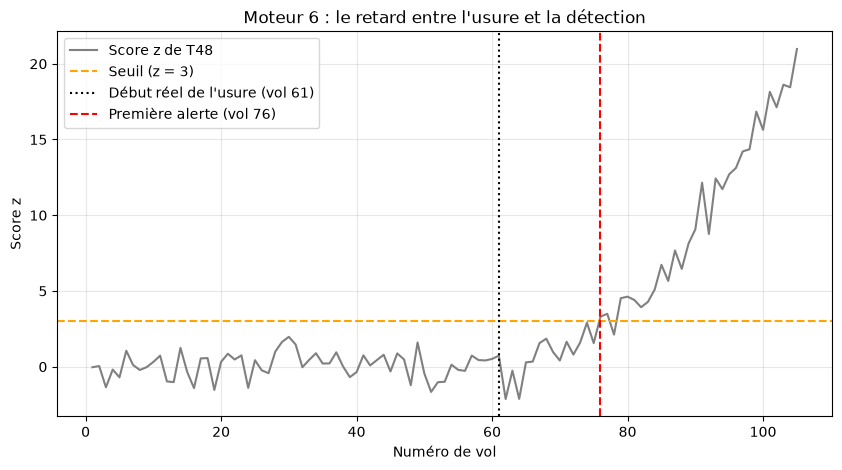

In [10]:
moteur = test[test["unit"] == 6]
debut_usure = moteur.loc[moteur["hs"] == 1, "cycle"].max()
premiere_alerte = moteur.loc[moteur["alerte"] & (moteur["hs"] == 0), "cycle"].min()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(moteur["cycle"], moteur["z"], color="gray", label="Score z de T48")
ax.axhline(3, color="orange", linestyle="--", label="Seuil (z = 3)")
ax.axvline(debut_usure, color="black", linestyle=":", label=f"Début réel de l'usure (vol {debut_usure})")
ax.axvline(premiere_alerte, color="red", linestyle="--", label=f"Première alerte (vol {premiere_alerte})")

ax.set_title("Moteur 6 : le retard entre l'usure et la détection")
ax.set_xlabel("Numéro de vol")
ax.set_ylabel("Score z")
ax.legend()
ax.grid(alpha=0.3)
fig.savefig("../results/figures/01_detection_moteur6.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

### 1. Résultats avec le seuil z = 3
- **Retard moyen de détection : 13,4 vols** après le début réel de l'usure.
- **Avance d'alerte moyenne : 26,8 vols** avant la panne.
- **1 fausse alarme** sur l'ensemble des vols sains des 5 moteurs de test.

### 2. Le cas du moteur 9 : un coup de chance du bruit
Le moteur 9 semble détecté seulement 3 vols après le début de l'usure (vol 63), mais c'est un faux succès :
- au vol 63, l'usure n'ajoute que 0,45 °C (0,05 × 3²) ; le pic à 535 °C vient du **bruit** du capteur ;
- dès le vol suivant, le score z retombe à −1,6 ;
- la vraie détection de l'usure n'arrive qu'au vol 74, soit 14 vols après le début de l'usure, comme les autres moteurs.

**Leçon :** une seule alerte isolée n'est pas fiable. Il faudrait exiger plusieurs alertes de suite avant de déclencher la maintenance.

### 3. Le compromis du seuil

| Seuil | Retard moyen | Avance d'alerte moyenne | Fausses alarmes |
|---|---|---|---|
| 2,5 | 11,4 vols | 28,8 vols | 3 |
| 3 | 13,4 vols | 26,8 vols | 1 |
| 4 | 18,8 vols | 21,4 vols | 0 |

- **Seuil bas** : on détecte plus tôt, mais on a plus de fausses alarmes.
- **Seuil haut** : aucune fausse alarme, mais on détecte plus tard.

Aucun seuil n'est parfait : il faut choisir selon le coût d'une fausse alarme (immobiliser un avion pour rien) et le coût d'une détection tardive (risque de panne).

### 4. Limite de la méthode
Le score z sur un seul capteur (T48) détecte l'usure environ 13 vols trop tard. Les prochaines méthodes (plusieurs capteurs combinés, XGBoost, autoencodeur) devront faire mieux : ce score z devient la **baseline** d'AeroGuard.